In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import holidays
import json
import requests
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")

# Instanciamos el calendario oficial
festivos_espana = holidays.ES(years=[2024, 2025, 2026])

In [2]:
# 1. CARGA DE DATOS MAESTROS
df_visitas = pd.read_csv('../data/dataset_global_raw.csv')
df_visitas['fecha'] = pd.to_datetime(df_visitas['fecha'])

# 2. LECTURA DEL JSON DE UBICACIONES
with open('../data/todas_las_ubicaciones.json', 'r', encoding='utf-8') as f:
    datos_loc = json.load(f)

mapa_regiones, mapa_nombres, mapa_coords = {}, {}, {}
for org in datos_loc:
    for loc in org.get('locations', []):
        mapa_nombres[loc['uuid']] = loc['name']
        if 'region_code' in loc: mapa_regiones[loc['uuid']] = loc['region_code']
        if 'latitude' in loc and 'longitude' in loc:
            mapa_coords[loc['uuid']] = (loc['latitude'], loc['longitude'])

# 3. SELECCIÓN DE TARGET (Málaga Muelle 1 - Calle)
uuid_objetivo = '67034276-0d01-4c90-a363-fa75699a19a4'
zona_objetivo = '79c9c568-41e1-43b3-84d4-e413630fa58a'

nombre_objetivo = mapa_nombres.get(uuid_objetivo, "Ubicacion Desconocida")
lat, lon = mapa_coords.get(uuid_objetivo, (36.7186, -4.4131))

# 4. EXTRACCIÓN DEL CLIMA VÍA API OPEN-METEO
fecha_min = df_visitas['fecha'].min().strftime('%Y-%m-%d')
fecha_max = df_visitas['fecha'].max().strftime('%Y-%m-%d')

url_clima = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={fecha_min}&end_date={fecha_max}&daily=temperature_2m_max,temperature_2m_min,precipitation_sum&timezone=Europe%2FMadrid"
respuesta = requests.get(url_clima).json()

df_clima = pd.DataFrame({
    'fecha': pd.to_datetime(respuesta['daily']['time']),
    'temp_max': respuesta['daily']['temperature_2m_max'],
    'temp_min': respuesta['daily']['temperature_2m_min'],
    'precipitacion': respuesta['daily']['precipitation_sum']
})
df_clima['llueve'] = (df_clima['precipitacion'] > 0).astype(int)

# 5. ENSAMBLAJE DEL DATAFRAME MAESTRO
df_master = pd.merge(df_visitas, df_clima, on='fecha', how='left')
df_master['region_code'] = df_master['location_id'].map(mapa_regiones)

# Filtrar y agrupar por tienda/zona
df_tienda = df_master[(df_master['location_id'] == uuid_objetivo) & (df_master['zone_uuid'] == zona_objetivo)].copy()
df_tienda = df_tienda.groupby('fecha').agg({
    'total_visits': 'sum', 'llueve': 'max', 'temp_max': 'max', 'temp_min': 'min'
}).reset_index().sort_values('fecha').reset_index(drop=True)

print(f"Dataset de {nombre_objetivo} preparado: {len(df_tienda)} días de histórico.")

Dataset de Malaga Muelle 1 preparado: 226 días de histórico.


In [3]:
# 1. PARÁMETROS DEL SIMULADOR
fecha_corte_test = pd.to_datetime('2026-04-01')
horizonte_dias = 14

# 2. CREACIÓN DEL CONTEXTO (TRAIN SET EXCLUSIVO)
train = df_tienda[df_tienda['fecha'] < fecha_corte_test].copy()

# Variables estáticas
train['es_festivo'] = train['fecha'].apply(lambda d: 1 if d in festivos_espana else 0)
train['es_finde'] = train['fecha'].dt.dayofweek.isin([5, 6]).astype(int)
train['dia_semana'] = train['fecha'].dt.dayofweek
train['dia_mes'] = train['fecha'].dt.day
train['mes'] = train['fecha'].dt.month
train['quincena'] = (train['dia_mes'] > 15).astype(int)
train['vispera_festivo'] = train['fecha'].apply(lambda d: 1 if (d + timedelta(days=1)) in festivos_espana else 0)
train['mucho_calor'] = (train['temp_max'] >= 32.0).astype(int)
train['mucho_frio'] = (train['temp_min'] <= 8.0).astype(int)
train['clima_ideal'] = ((train['temp_max'] >= 18.0) & (train['temp_max'] <= 26.0) & (train['llueve'] == 0)).astype(int)
train['finde_lluvioso'] = train['es_finde'] * train['llueve']

# Lags exclusivos del Train Set (Sin fugar el futuro)
train['lag_1d'] = train['total_visits'].shift(1)
train['lag_7d'] = train['total_visits'].shift(7)
train['media_7d'] = train['total_visits'].rolling(7).mean()
train['lag_14d'] = train['total_visits'].shift(14)
train['media_14d'] = train['total_visits'].rolling(14).mean()
train['std_7d'] = train['total_visits'].rolling(7).std().fillna(0)

train = train.dropna().reset_index(drop=True)

features = ['es_finde', 'es_festivo', 'llueve', 'dia_semana', 'dia_mes', 'mes', 
            'lag_1d', 'lag_7d', 'media_7d', 'quincena', 'vispera_festivo', 
            'lag_14d', 'media_14d', 'std_7d', 'finde_lluvioso', 'mucho_calor', 'mucho_frio', 'clima_ideal']

# 3. ENTRENAMIENTO HERMÉTICO (Split 85/15)
X_train, y_train = train[features], train['total_visits']
split_idx = int(len(X_train) * 0.85)
X_t, y_t = X_train.iloc[:split_idx], y_train.iloc[:split_idx]
X_v, y_v = X_train.iloc[split_idx:], y_train.iloc[split_idx:]

modelo = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=3, early_stopping_rounds=20,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.5, min_child_weight=7, random_state=42
)
print("Iniciando entrenamiento hermético...")
modelo.fit(X_t, y_t, eval_set=[(X_t, y_t), (X_v, y_v)], verbose=False)
print(f"✓ Modelo congelado en la iteración: {modelo.best_iteration}")

# 4. PREDICCIÓN AUTORREGRESIVA (EL FUTURO DÍA A DÍA)
df_work = df_tienda[df_tienda['fecha'] < fecha_corte_test].copy()
fechas_pred, valores_pred, valores_reales = [], [], []

for i in range(horizonte_dias):
    current_date = fecha_corte_test + timedelta(days=i)
    fechas_pred.append(current_date)
    
    # Extraemos el clima real si existe (backtesting)
    real_row = df_tienda[df_tienda['fecha'] == current_date]
    tiene_real = not real_row.empty
    llueve = real_row['llueve'].values[0] if tiene_real else 0
    t_max = real_row['temp_max'].values[0] if tiene_real else 22.0
    t_min = real_row['temp_min'].values[0] if tiene_real else 12.0
    
    real_visits = real_row['total_visits'].values[0] if tiene_real else np.nan
    valores_reales.append(real_visits)

    # Variables de calendario
    es_festivo = 1 if current_date in festivos_espana else 0
    es_finde = 1 if current_date.dayofweek in [5, 6] else 0

    # Lags Dinámicos (Se leen del DataFrame de trabajo que incluye las predicciones anteriores)
    visits_array = df_work['total_visits'].values
    
    row = pd.DataFrame([{
        'es_finde': es_finde, 'es_festivo': es_festivo, 'llueve': llueve,
        'dia_semana': current_date.dayofweek, 'dia_mes': current_date.day, 'mes': current_date.month,
        'lag_1d': visits_array[-1] if len(visits_array) >= 1 else 0,
        'lag_7d': visits_array[-7] if len(visits_array) >= 7 else 0,
        'media_7d': np.mean(visits_array[-7:]) if len(visits_array) >= 7 else 0,
        'quincena': 1 if current_date.day > 15 else 0,
        'vispera_festivo': 1 if (current_date + timedelta(days=1)) in festivos_espana else 0,
        'lag_14d': visits_array[-14] if len(visits_array) >= 14 else 0,
        'media_14d': np.mean(visits_array[-14:]) if len(visits_array) >= 14 else 0,
        'std_7d': np.std(visits_array[-7:]) if len(visits_array) >= 7 else 0,
        'finde_lluvioso': es_finde * llueve,
        'mucho_calor': 1 if t_max >= 32.0 else 0, 'mucho_frio': 1 if t_min <= 8.0 else 0,
        'clima_ideal': 1 if (18.0 <= t_max <= 26.0 and llueve == 0) else 0
    }])

    # Predecir e inyectar al final del dataset
    pred = np.maximum(0, np.round(modelo.predict(row[features])[0]))
    valores_pred.append(pred)
    df_work = pd.concat([df_work, pd.DataFrame({'fecha': [current_date], 'total_visits': [pred]})], ignore_index=True)

# 5. RESULTADOS
reales_validos = [r for r in valores_reales if pd.notna(r)]
pred_validos = valores_pred[:len(reales_validos)]

mae = mean_absolute_error(reales_validos, pred_validos)
wmape = np.sum(np.abs(np.array(reales_validos) - np.array(pred_validos))) / np.sum(reales_validos)
accuracy = (1 - wmape) * 100

print(f"RESULTADOS DEL BACKTESTING ({len(reales_validos)} días evaluados)")
print(f"MAE: {mae:.1f} visitas | WMAPE: {wmape*100:.2f}% | Accuracy Real: {accuracy:.2f}%")

Iniciando entrenamiento hermético...
✓ Modelo congelado en la iteración: 163
RESULTADOS DEL BACKTESTING (14 días evaluados)
MAE: 2407.5 visitas | WMAPE: 18.76% | Accuracy Real: 81.24%


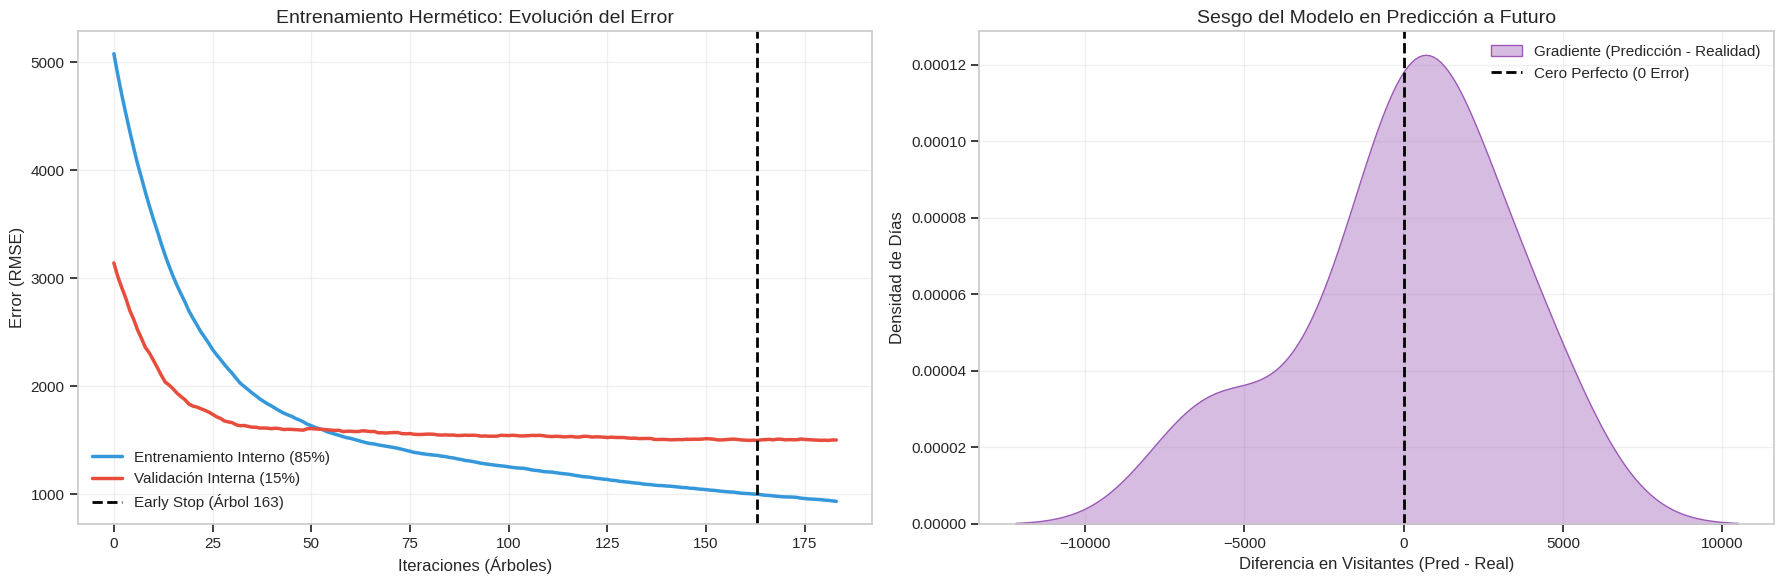

In [4]:
resultados = modelo.evals_result()
epochs = len(resultados['validation_0']['rmse'])
x_axis = range(0, epochs)

gradiente_test = np.array(pred_validos) - np.array(reales_validos)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Early Stopping Interno
ax1.plot(x_axis, resultados['validation_0']['rmse'], label='Entrenamiento Interno (85%)', color='#3498db', linewidth=2.5)
ax1.plot(x_axis, resultados['validation_1']['rmse'], label='Validación Interna (15%)', color='#e74c3c', linewidth=2.5)
ax1.axvline(modelo.best_iteration, color='black', linestyle='--', linewidth=2, label=f'Early Stop (Árbol {modelo.best_iteration})')
ax1.set_title('Entrenamiento Hermético: Evolución del Error', fontsize=14)
ax1.set_xlabel('Iteraciones (Árboles)')
ax1.set_ylabel('Error (RMSE)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Gradiente (Sesgo de Predicción Autorregresiva)
sns.kdeplot(gradiente_test, ax=ax2, label='Gradiente (Predicción - Realidad)', color='#9b59b6', fill=True, alpha=0.4)
ax2.axvline(0, color='black', linestyle='--', linewidth=2, label='Cero Perfecto (0 Error)')
ax2.set_title('Sesgo del Modelo en Predicción a Futuro', fontsize=14)
ax2.set_xlabel('Diferencia en Visitantes (Pred - Real)')
ax2.set_ylabel('Densidad de Días')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Convertimos las listas de resultados en un DataFrame para Plotly
df_res = pd.DataFrame({
    'fecha': fechas_pred,
    'realidad': valores_reales,
    'prediccion': valores_pred
})

fig = go.Figure()

# Trazado Realidad
fig.add_trace(go.Scatter(
    x=df_res['fecha'], y=df_res['realidad'],
    mode='lines+markers', name='Datos Reales',
    line=dict(color='#bdc3c7', width=2),
    marker=dict(size=6, color='#7f8c8d')
))

# Trazado Predicción Iterativa
fig.add_trace(go.Scatter(
    x=df_res['fecha'], y=df_res['prediccion'],
    mode='lines+markers', name='Predicción Autorregresiva',
    line=dict(color='#27ae60', width=3, dash='dot', shape='spline'),
    marker=dict(size=8, symbol='diamond', color='#2ecc71')
))

# Errores diarios interactivos
for index, row in df_res.dropna().iterrows():
    fig.add_trace(go.Scatter(
        x=[row['fecha'], row['fecha']],
        y=[row['realidad'], row['prediccion']],
        mode='lines', line=dict(color='rgba(231, 76, 60, 0.4)', width=1, dash='solid'),
        showlegend=False, hoverinfo='skip'
    ))

fig.update_layout(
    title=dict(text=f"Backtesting Predictivo: {nombre_objetivo}", font=dict(size=18, color='#2c3e50')),
    xaxis_title='Fecha de Simulación',
    yaxis_title='Volumen de Visitantes',
    hovermode='x unified',
    template='plotly_white',
    legend=dict(orientation="h", y=1.1, x=0.5, xanchor='center')
)

fig.show()